<a href="https://colab.research.google.com/github/mweb4100/CS4410-Homework/blob/main/homework6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
%pip install -q nltk textblob wordcloud matplotlib requests imageio

import nltk
import requests
import numpy as np
import matplotlib.pyplot as plt
import imageio.v3 as imageio

from io import BytesIO
from textblob import TextBlob
from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [12]:
target_url = "https://www.gutenberg.org/files/2265/2265-0.txt"

response = requests.get(target_url, timeout=30)
response.raise_for_status()

data = response.text
blob = TextBlob(data)

print("Hamlet downloaded successfully!")
print("Total characters:", len(data))

Hamlet downloaded successfully!
Total characters: 171696


In [13]:
stop_words = set(stopwords.words('english'))

words = [
    word.lower()
    for word in blob.words
    if word.isalpha()
    and word.lower() not in stop_words
]

word_counts = Counter(words)
top_20 = word_counts.most_common(20)

print("Top 20 Most Frequent Words in Hamlet:")

for word, count in top_20:
    print(f"{word}: {count}")

Top 20 Most Frequent Words in Hamlet:
ham: 337
lord: 211
haue: 175
king: 173
shall: 107
come: 106
thou: 105
let: 104
hamlet: 100
good: 98
hor: 95
thy: 90
enter: 85
oh: 81
like: 78
well: 70
may: 69
know: 69
selfe: 68
would: 68


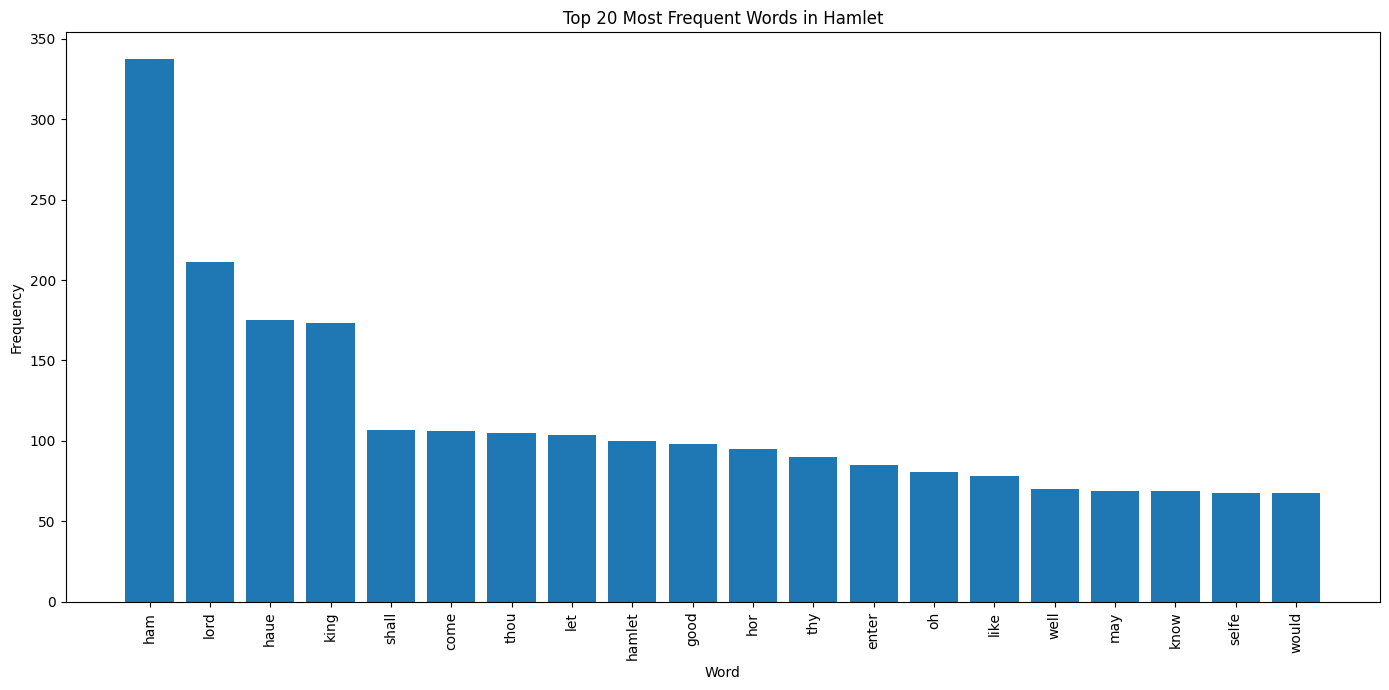

In [14]:
labels = [word for word, count in top_20]
frequencies = [count for word, count in top_20]

plt.figure(figsize=(14, 7))
plt.bar(labels, frequencies)

plt.title("Top 20 Most Frequent Words in Hamlet")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [15]:
import imageio.v3 as imageio

mask_image = imageio.imread('/content/mask_oval.png')

print("Original mask loaded successfully!")


Original mask loaded successfully!


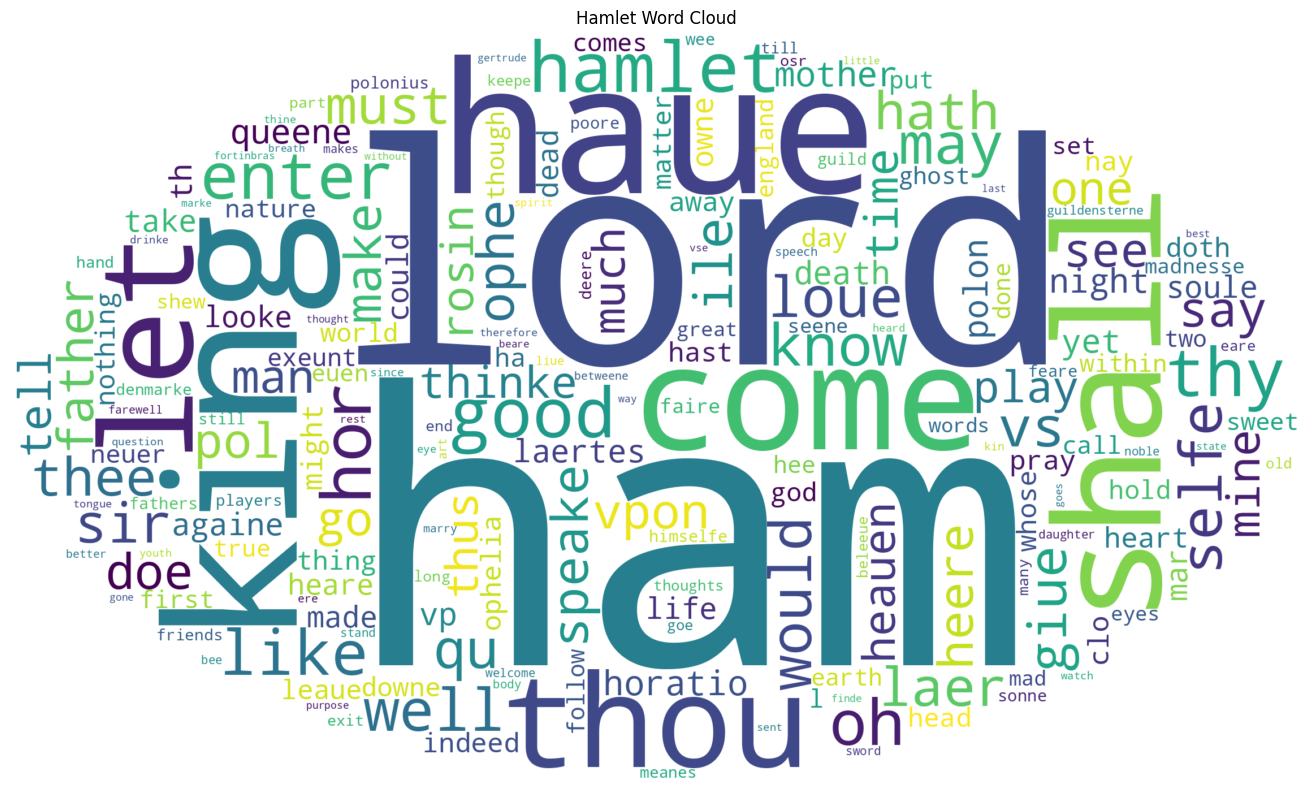

In [16]:
wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    mask=mask_image,
    colormap="viridis",
    max_words=200,
    random_state=42
).generate_from_frequencies(word_counts)

plt.figure(figsize=(14, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Hamlet Word Cloud")

plt.tight_layout()
plt.show()